In [2]:
from enum import StrEnum


class Branch(StrEnum):
    FT = 'factor-trimming'
    FT_NC = 'factor-trimming-no-collect'
    FT_NUC = 'factor-trimming-no-universe-check'
    FT_NUC_AHASH = 'ft-nuc-ahash'
    FT_NUC_FXHASH = 'ft-nuc-fxhash'
    FT_NUC_NOHASH = 'ft-nuc-nohash'
    FT_NUC_NOHASH_LCP = 'ft-nuc-nohash-lcp'
    FT_NUC_NOHASH_LCP_ENUM = 'ft-nuc-nohash-lcp-enum'
    GROUNDUP = 'groundup'
    GROUNDUP_LCP = 'groundup-lcp'
    GROUNDUP_LCP_JOIN = 'groundup-lcp-join'
    GROUNDUP_LCP_JOIN_TEMP = 'groundup-lcp-join-temp'
    GROUNDUP_LCP_JOIN_HEURISTICS = 'groundup-lcp-join-heuristics'
    GROUNDUP_LCP_JOIN_NC_HEURISTICS = 'groundup-lcp-join-nc-heuristics'
    GROUNDUP_LCP_MEMO = 'groundup-lcp-memo'
    GROUNDUP_LCP_MEMO_HEURISTICS = 'groundup-lcp-memo-heuristics'
    GROUNDUP_LCP_NC_HEURISTICS = 'groundup-lcp-nc-heuristics'
    GROUNDUP_LCP_PREGEN = 'groundup-lcp-pregen'
    LCP = 'lcp'
    LCP_FACTORS = 'lcp-factors'
    MAIN = 'main'
    NAIVE = 'naive'
    NAIVE_NC = 'naive-no-collect'
    NAIVE_NUC = 'naive-no-universe-check'
    NC_NUC = 'nc-nuc'
    NC_NUC_NOHASH = 'nc-nuc-nohash'
    PARALLEL = 'parallel'


pretty_branch_names = {
    str(Branch.FT): "Heuristics",
    str(Branch.FT_NC): "",
    str(Branch.FT_NUC): "stdlib Hash",
    str(Branch.FT_NUC_AHASH): "A Hash",
    str(Branch.FT_NUC_FXHASH): "FX Hash",
    str(Branch.FT_NUC_NOHASH): "No Hash",
    str(Branch.FT_NUC_NOHASH_LCP): "",
    str(Branch.FT_NUC_NOHASH_LCP_ENUM): "Best Naive",
    str(Branch.GROUNDUP): "V2",
    str(Branch.GROUNDUP_LCP): "",
    str(Branch.GROUNDUP_LCP_JOIN): "Join Approach (old)",
    str(Branch.GROUNDUP_LCP_JOIN_TEMP): "",
    str(Branch.GROUNDUP_LCP_JOIN_HEURISTICS): "Join Approach (old)",
    str(Branch.GROUNDUP_LCP_JOIN_NC_HEURISTICS): "Join Approach",
    str(Branch.GROUNDUP_LCP_MEMO): "",
    str(Branch.GROUNDUP_LCP_MEMO_HEURISTICS): "Elimination Approach (memo)",
    str(Branch.GROUNDUP_LCP_NC_HEURISTICS): "Elimination Approach",
    str(Branch.GROUNDUP_LCP_PREGEN): "",
    str(Branch.LCP): "",
    str(Branch.LCP_FACTORS): "",
    str(Branch.MAIN): "Main",
    str(Branch.NAIVE): "Total Brute Force",
    str(Branch.NAIVE_NC): "Brute Force w/ iter",
    str(Branch.NAIVE_NUC): "Brute Force NUC",
    str(Branch.NC_NUC): "",
    str(Branch.NC_NUC_NOHASH): "Brute force no hash",
    str(Branch.PARALLEL): "",

}

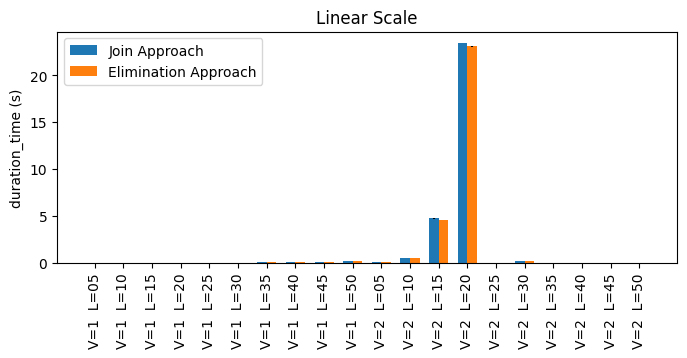

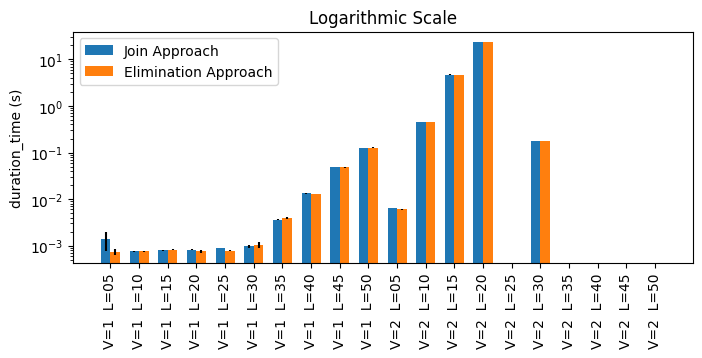

In [5]:
import json
from marker.perf import PerfEvent, plot_results
import matplotlib.pyplot as plt

timestamp = "2026-05-15 12-29-12"
name = "growing_disjunctions"

with open(f"./out/report/{name}/{timestamp}/data.json") as f:
    results = json.load(f)

dims = (8, 3)
# dims = (12, 3)
num_words = 10
word_growth_step = 5
max_n_vars = 5
case_labels = [
    f"V={v+1}  L={l:02}" for v in range(max_n_vars) for l in range(word_growth_step, (num_words+1)*word_growth_step, word_growth_step)
]


plot_results(PerfEvent.DURATION_TIME, results, dimensions=dims, x_rotation=90,
             branch_labels=pretty_branch_names, case_labels=case_labels)
plt.legend(loc="upper left")
plt.title("Linear Scale")
plt.savefig(f"./out/report/{name}/{timestamp}/modified_plot.png", bbox_inches="tight", dpi=300)
plot_results(PerfEvent.DURATION_TIME, results, log_scale=True,
             dimensions=dims, x_rotation=90, branch_labels=pretty_branch_names, case_labels=case_labels)
plt.title("Logarithmic Scale")
plt.legend(loc="upper left")
plt.savefig(f"./out/report/{name}/{timestamp}/modified_plot_log.png", bbox_inches="tight", dpi=300)